Dataset Preview:
   joint_value_FR_Thigh   accel_x   accel_y  accel_z  foot_force  \
0             -0.697793  0.500388 -0.013168  9.23444          23   
1             -0.695299  0.500388 -0.013168  9.23444          23   
2             -0.650596  0.500388 -0.013168  9.23444          23   
3             -0.680164  0.539892 -0.062249  8.99621          23   
4             -0.683732  0.539892 -0.062249  8.99621          23   

   Label (stand : 1, Sit : 0)  
0                           1  
1                           1  
2                           1  
3                           1  
4                           1  

Feature most correlated with label: joint_value_FR_Thigh
Correlation value: 0.9966066225444268


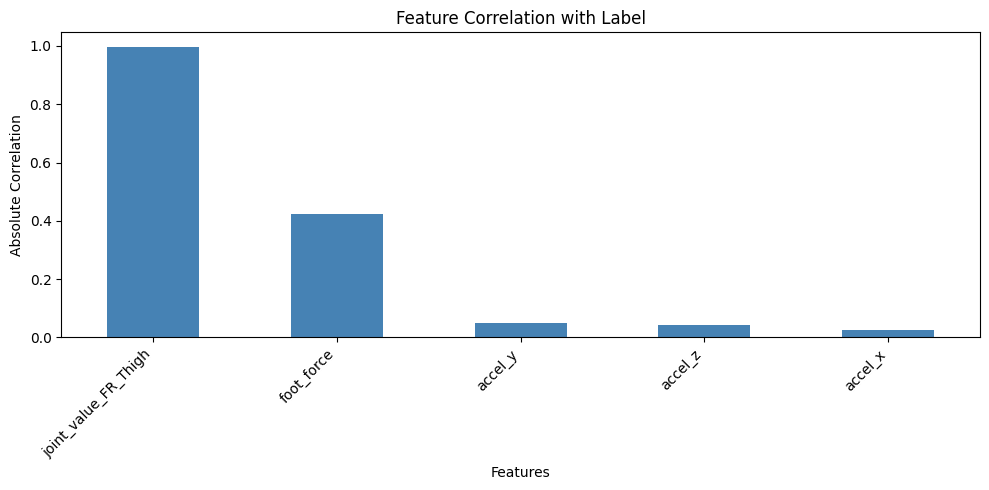

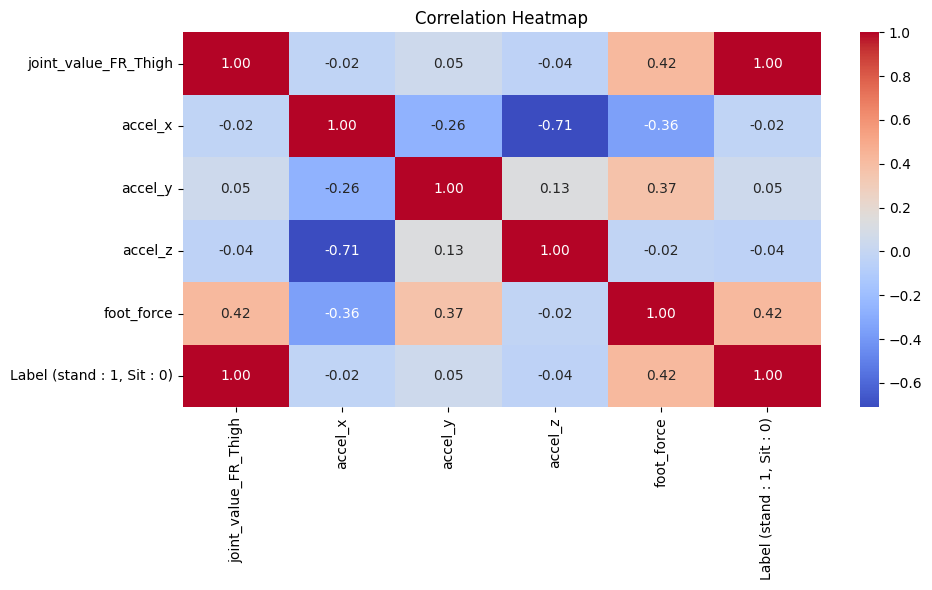


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       193
           1       1.00      1.00      1.00       207

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
data = pd.read_csv("Go2_SensorData.csv")
print("Dataset Preview:")
print(data.head())
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
correlations = X.apply(lambda col: abs(col.corr(y)))
best_feature = correlations.idxmax()
print("\nFeature most correlated with label:", best_feature)
print("Correlation value:", correlations.max())
plt.figure(figsize=(10, 5))
correlations.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title("Feature Correlation with Label")
plt.ylabel("Absolute Correlation")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)x
y_pred = svm_model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         sit       1.00      1.00      1.00         5
       Stand       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



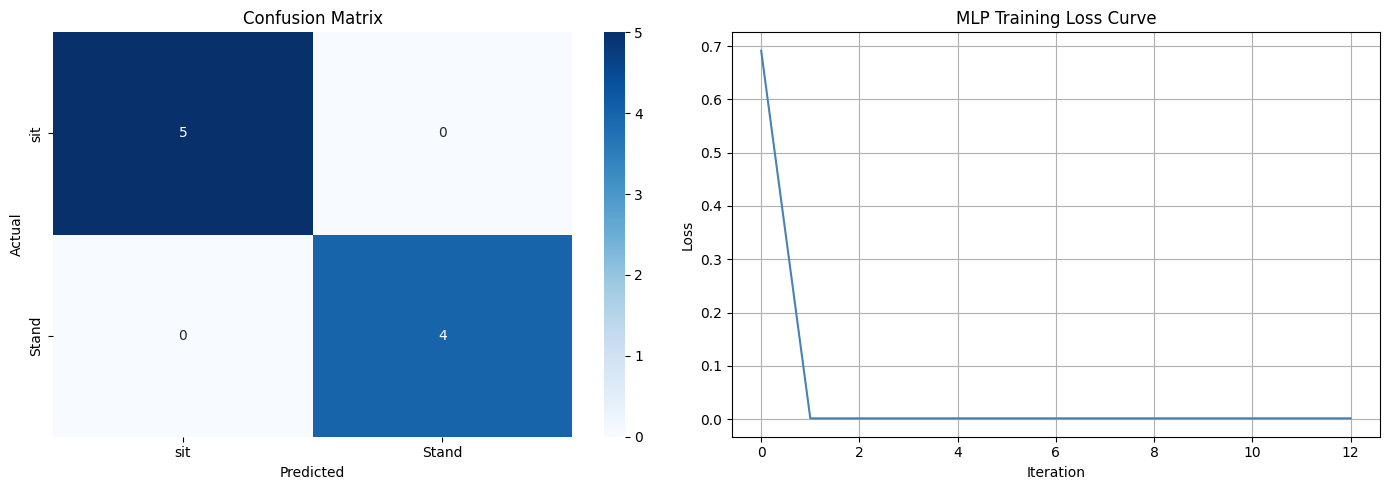

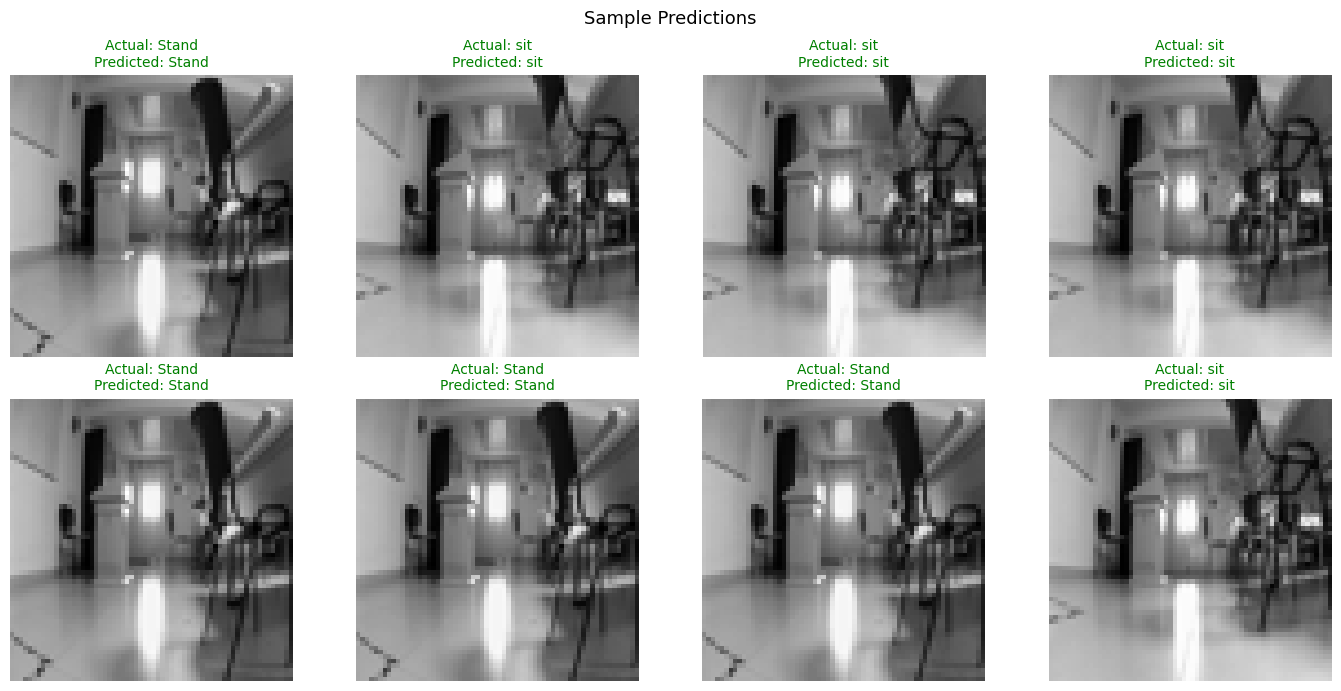

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import zipfile

ImageFile.LOAD_TRUNCATED_IMAGES = True
IMG_SIZE = (64, 64)

# Unzip the dataset if not already extracted
zip_file_path = "Lab9_1. MLP - Sit_StandClassify_img.zip"
extract_dir = "Lab9_1. MLP - Sit_StandClassify_img"

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # Corrected: extract to the specified extract_dir
        zip_ref.extractall(extract_dir)

DATA_DIR = os.path.join(extract_dir, "1. MLP - Sit_StandClassify_img")
CLASSES = {"sit": 0, "Stand": 1}
images, labels, raw_imgs, raw_labels = [], [], [], []

for cls_name, cls_idx in CLASSES.items():
    folder = os.path.join(DATA_DIR, cls_name)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            img = Image.open(os.path.join(folder, fname)).convert('L').resize(IMG_SIZE)
            images.append(np.array(img).flatten() / 255.0)
            labels.append(cls_idx)
            raw_imgs.append(np.array(img))
            raw_labels.append(cls_name)

X = np.array(images)
y = np.array(labels)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, list(range(len(y))), test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu',max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
label_names = ["sit", "Stand"]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")
loss_curve = mlp.loss_curve_
axes[1].plot(loss_curve, color='steelblue')
axes[1].set_title("MLP Training Loss Curve")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss")
axes[1].grid(True)
plt.tight_layout()
plt.show()
n_show = min(8, len(idx_test))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for i in range(n_show):
    orig_idx = idx_test[i]
    axes[i].imshow(raw_imgs[orig_idx], cmap='gray')
    actual = raw_labels[orig_idx]
    predicted = label_names[y_pred[i]]
    color = 'green' if actual == predicted else 'red'
    axes[i].set_title(f"Actual: {actual}\nPredicted: {predicted}", color=color, fontsize=10)
    axes[i].axis('off')
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.suptitle("Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()